In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pandas as pd
import rubin_sim
import rubin_sim.maf as maf
#from rubin_sim.data import get_baseline
print(rubin_sim.__version__)
from os.path import splitext, basename
from rubin_scheduler.scheduler.utils import SkyAreaGenerator

from rubin_sim.data import get_baseline

2.4.1.dev0+ge6735eb76.d20251021


/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric TotalPowerMetric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric StaticProbesFoMEmulatorMetricSimple! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric NestedRIZExptimeExgalM5Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))


In [2]:
# fixing a weird issue
#import os
#os.environ['RUBIN_SIM_DATA_DIR'] = '~/rubin_sim_data'
#os.environ['RUBIN_SIM_DATA_DIR'] 

# Demo of Tomographic Sigma8 bias Metric

In [3]:
from rubin_sim.maf.metrics.uniformity_metrics import NestedLinearMultibandModelMetric
from rubin_sim.maf.metrics.cosmology_summary_metrics import TomographicClusteringSigma8biasMetric

In [4]:
from rubin_sim.maf.metrics.tomography_models import DENSITY_TOMOGRAPHY_MODEL
# this contains the current model.
# the first set of keys are the years (year1, ..., year10) since this would change typical depth and galaxy catalog cuts.
# in what follows we have 5 tomographic bins.
# the second nested dictionary has the following:
# sigma8square_model is the fiducial sigma8^2 value used in CCL for the theory predictions
# poly1d_coefs_loglog is a polynomial (5th degree) describing the angular power spectra (in log log space) in the 5 tomographic bins considered, thus has shape (5, 6)
# lmax contains the lmax limits to sum the Cells over when calculating sigma8 for each tomographic bin. thus is it of shape (5, )
# dlogN_dm5 contains the derivatives of logN wrt m5 calculated in Qianjun & Jeff's simulations. It is an array of 5 dictionaries (5 = the tomographic bins)
# each dictionary must have keys that are the lsst bands. If some are missing they are ignored in the linear model.
# they are the ones which will be fed to LinearMultibandModelMetric. Everything else above is going into the modeling 
# The notebook I used to make this dictionary is https://github.com/ixkael/ObsStrat/blob/meanz_uniformity_maf/code/meanz_uniformity/romanrubinmock_for_sigma8tomography.ipynb

In [5]:
# a simple wrapper around the metrics, to store the results, but not critically needed
def extract_sigma8_tomography_metric(
    opsim_fname, run_fname,
    years, 
    percentage_uncorrected,
    density_tomography_model, 
    lmin = 10,
    mag_range_tolerated=1.0,
    n_filters = 6, 
    extinction_cut = 0.2, # sky cuts
    nside=32,
    convert_to_sigma8=True
):
    surveyAreas = SkyAreaGenerator(nside=nside)
    map_footprints, map_labels = surveyAreas.return_maps()
    slicer = maf.HealpixSubsetSlicer(
        nside=nside, 
        hpid=np.where(map_labels == "lowdust")[0],#hpid=np.arange(hp.nside2npix(nside)), 
        use_cache=False)
    
    # prepare empty arrays to fill in the results
    n_bins = 5 # set to 5
    results_spuriousdensitypower = np.zeros((len(years), n_bins))
    results_sigma8_squared_bias = np.zeros((len(years), ))
    # loop over years
    all_depth_map_bundles = []
    for iy, year in enumerate(years):
        print('year', year)
        
        # constraints
        days = year*365.25
        constraint_str = 'scheduler_note not like "DD%" and night <= XX and scheduler_note not like "twilight_near_sun" '
        constraint_str = constraint_str.replace('XX','%d'%days)
    
        # leave empty if not specified
        mean_depth = {}
        min_depth_cut = {} 
        max_depth_cut = {}
       
        ##############################
        # now converts depth fluctuations to density fluctuations
        ##############################
        metric = NestedLinearMultibandModelMetric(
            density_tomography_model['year'+str(year)]['dlogN_dm5'], 
            extinction_cut=extinction_cut, n_filters=n_filters, # cuts going into ExgalM5WithCuts
            mean_depth=mean_depth, min_depth_cut=min_depth_cut, max_depth_cut=max_depth_cut,
        )
        # summary metric measures total power via angular power spectra of healpix map (thus needs nside)
        # _but_ has a bin-dependent lmax to consider same scales to consider the same scales as a fct of redshift
        summary_metrics = [
            TomographicClusteringSigma8biasMetric(
                density_tomography_model['year'+str(year)], convert_to_sigma8=convert_to_sigma8,
                power_multiplier=percentage_uncorrected, lmin=lmin),
        ]
        # then standard way of packing MetricBundles into a MetricBundleGroup
        depth_map_bundles = [maf.MetricBundle(
            metric=metric,
            slicer=slicer,
            constraint=constraint_str,
            run_name=run_name,
            summary_metrics=summary_metrics
        )]
        bd = maf.metricBundles.make_bundles_dict_from_list(depth_map_bundles)
        bgroup = maf.MetricBundleGroup(bd, opsim_fname)
        bgroup.run_all()

        # compute bias
        # should probably also return fsky
        results_sigma8_squared_bias[iy] = depth_map_bundles[0].summary_values['TomographicClusteringSigma8bias']
        all_depth_map_bundles.append(depth_map_bundles[0])

    return results_sigma8_squared_bias, all_depth_map_bundles

In [6]:
baseline_file = get_baseline()
baseline_file

'/Users/yoachim/rubin_sim_data/sim_baseline/baseline_v5.0.0_10yrs.db'

In [7]:
#baseline_file = get_baseline()
sim_list = [baseline_file
]
name_list = [splitext(basename(sim))[0] for sim in sim_list]

years = range(1, 11)  # [1, 2, 4, 7, 10]#
percentage_uncorrected = 0.1

# large mag_range_tolerated and no min depth in order to make comparison fair between strategies etc
results_fsky = {}
results_sigma8_squared_bias = {}
for opsim_fname, run_name in zip(sim_list, name_list):
    
    print('run_name:', run_name)
    results_sigma8_squared_bias[run_name], _ = extract_sigma8_tomography_metric(
        opsim_fname, run_name,
        years, 
        percentage_uncorrected,
        DENSITY_TOMOGRAPHY_MODEL,
        nside=64,
        lmin=10, n_filters=6, extinction_cut=0.2, mag_range_tolerated=2.0,
        convert_to_sigma8=True
    )
    
    

run_name: baseline_v5.0.0_10yrs
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
year 1


/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/maps/dust_map.py:46: UserWarning: Slicer value of nside 64 different from map value 128, using slicer value
  warnings.warn(
/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/metrics/cosmology_summary_metrics.py:73: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  data = hp.remove_monopole(data, verbose=False, bad=self.mask_val)
/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/metrics/cosmology_summary_metrics.py:75: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  data = hp.remove_dipole(data, verbose=False, bad=self.mask_val)


spuriousdensitypowers: [0.00568099 0.00622485 0.00399589 0.00128107 0.016763  ]
fskys: [0.40405994 0.40405994 0.40405994 0.40405994 0.40405994]
0.6400000000000001 0.6623500832062111 0.005453857495016782 4.098032122517393
0.8 0.8138489314401114 0.003350657157813148 4.1331985899596
year 2
spuriousdensitypowers: [0.02120177 0.01728666 0.00693721 0.0046805  0.00184558]
fskys: [0.40415986 0.40415986 0.40415986 0.40415986 0.40415986]
0.6400000000000001 0.6500411741131265 0.005413417437544279 1.8548678776343113
0.8 0.8062513095264568 0.0033571526480520027 1.8620867687038734
year 3
spuriousdensitypowers: [0.00661991 0.00819832 0.00337406 0.00193849 0.00055764]
fskys: [0.40415986 0.40415986 0.40415986 0.40415986 0.40415986]
0.6400000000000001 0.6439435189551981 0.005392792880939481 0.7312572617309481
0.8 0.8024609142850498 0.003360159220804027 0.7323802603797281
year 4
spuriousdensitypowers: [0.00316623 0.0044001  0.00232425 0.00151433 0.00107296]
fskys: [0.40415986 0.40415986 0.40415986 0.4041

Text(0, 0.5, 'Top panel minus baseline_v5.0.0_10yrs')

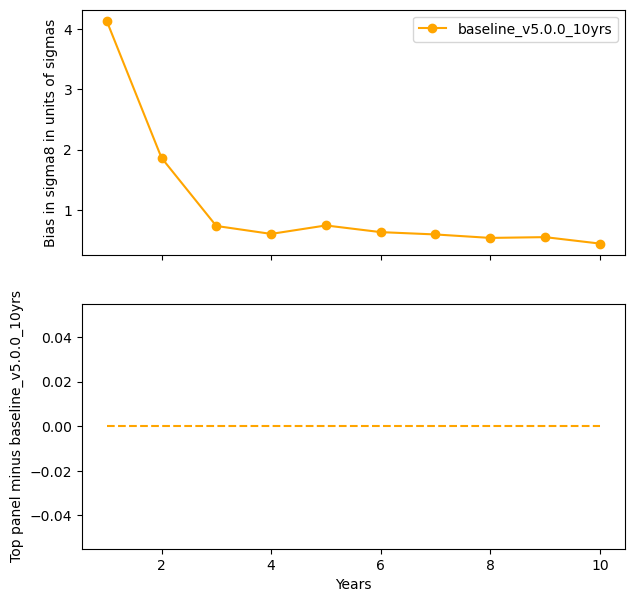

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

colors = ['orange', 'blue', 'black', 'red']
for i, run_name in enumerate(results_sigma8_squared_bias.keys()):
    axs[0].plot(years, results_sigma8_squared_bias[run_name], label=run_name, marker='o', color=colors[i])
axs[0].legend()

results_sigma8_squared_bias.keys()
axs[1].set_xlabel('Years')
axs[0].set_ylabel('Bias in sigma8 in units of sigmas')

run_name_ = list(results_sigma8_squared_bias.keys())[0]
for i, run_name in enumerate(results_sigma8_squared_bias.keys()):
    axs[1].plot(years, np.array(years)*0, ls='--', c='orange')
    if run_name != run_name_:
        axs[1].plot(years, results_sigma8_squared_bias[run_name]-results_sigma8_squared_bias[run_name_], label=run_name, marker='o', color=colors[i])
axs[1].set_ylabel('Top panel minus '+run_name_)

# Demo of AreaAtRisk metric

In [9]:
from rubin_sim.maf.metrics.cosmology_summary_metrics import UniformAreaFoMFractionMetric
from rubin_sim.maf.metrics.uniformity_metrics import NestedRIZExptimeExgalM5Metric
from rubin_sim.maf.metrics.weak_lensing_systematics_metric import RIZDetectionCoaddExposureTime, ExgalM5WithCuts
from rubin_sim.maf.metrics.exgal_m5 import ExgalM5

nside = 64

sim_list = [baseline_file]
name_list = [splitext(basename(sim))[0] for sim in sim_list]

years = range(1, 11) 
surveyAreas = SkyAreaGenerator(nside=nside)
map_footprints, map_labels = surveyAreas.return_maps()
slicer = maf.HealpixSubsetSlicer(
    nside=nside, 
    hpid=np.where(map_labels == "lowdust")[0],#hpid=np.arange(hp.nside2npix(nside)), 
    use_cache=False)

results_allruns= {}
for opsim_fname, run_name in zip(sim_list, name_list):

    results_allyears = np.zeros((len(years), ))
    # loop over years 
    for iy, year in enumerate(years):
        print('year', year)

        days = year*365.25
        constraint_str = 'scheduler_note not like "DD%" and night <= XX and scheduler_note not like "twilight_near_sun" '
        constraint_str = constraint_str.replace('XX','%d'%days)

        
        metric = NestedRIZExptimeExgalM5Metric(
            depth_cut=25.0 # what depth cuts to apply year after year?
        ) 
        summary_metrics = [UniformAreaFoMFractionMetric(
            year,
            nside=nside,
            verbose=False, 
            metric_name='FoMRatio'
        )]
        depth_map_bundles = [maf.MetricBundle(
            metric=metric,
            slicer=slicer,
            constraint=constraint_str,
            run_name=run_name,
            summary_metrics=summary_metrics
        )]
        bd = maf.metricBundles.make_bundles_dict_from_list(depth_map_bundles)
        bgroup = maf.MetricBundleGroup(bd, opsim_fname)
        bgroup.run_all()
        results_allyears[iy] = bd[list(bd.keys())[0]].summary_values['FoMRatio']
        
    results_allruns[run_name] = results_allyears

    

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
year 1


/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/maps/dust_map.py:46: UserWarning: Slicer value of nside 64 different from map value 128, using slicer value
  warnings.warn(


year 2
year 3


/Users/yoachim/anaconda3/envs/rubin12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/yoachim/anaconda3/envs/rubin12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/yoachim/anaconda3/envs/rubin12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


year 4


...

year 7
year 8


/Users/yoachim/anaconda3/envs/rubin12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/yoachim/anaconda3/envs/rubin12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/yoachim/anaconda3/envs/rubin12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


year 9


/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/maps/dust_map.py:46: UserWarning: Slicer value of nside 64 different from map value 128, using slicer value
  warnings.warn(


year 10


Text(0, 0.5, 'FOM ratio')

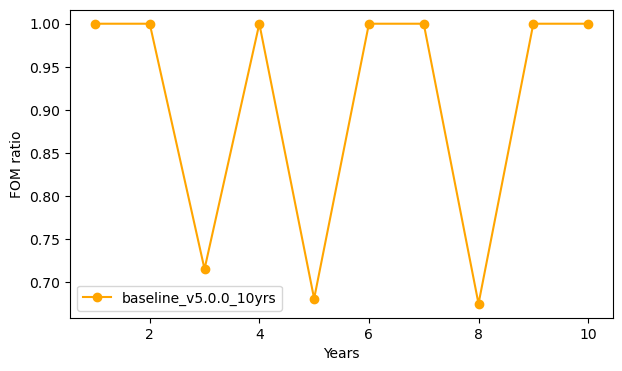

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(7, 4), sharex=True)
axs = [axs]
colors = ['orange', 'blue', 'black', 'red']
for i, run_name in enumerate(results_allruns.keys()):
    axs[0].plot(years, results_allruns[run_name], label=run_name, marker='o', color=colors[i])
axs[0].legend()

axs[0].set_xlabel('Years')
axs[0].set_ylabel('FOM ratio')

# Demo of meanz metric

In [11]:
from rubin_sim.maf.metrics.cosmology_summary_metrics import MultibandMeanzBiasMetric
from rubin_sim.maf.metrics.uniformity_metrics import MultibandExgalM5
from rubin_sim.maf.metrics.weak_lensing_systematics_metric import RIZDetectionCoaddExposureTime, ExgalM5WithCuts
from rubin_sim.maf.metrics.exgal_m5 import ExgalM5
from rubin_sim.maf.metrics.tomography_models import DENSITY_TOMOGRAPHY_MODEL, MEANZ_TOMOGRAPHY_MODEL

nside = 32

sim_list = [baseline_file]
name_list = [splitext(basename(sim))[0] for sim in sim_list]

years = range(1, 10) 
surveyAreas = SkyAreaGenerator(nside=nside)
map_footprints, map_labels = surveyAreas.return_maps()
slicer = maf.HealpixSubsetSlicer(
    nside=nside, 
    hpid=np.where(map_labels == "lowdust")[0],#hpid=np.arange(hp.nside2npix(nside)), 
    use_cache=False)

results_allruns= {}
for opsim_fname, run_name in zip(sim_list, name_list):

    results_allyears = np.zeros((len(years), ))
    # loop over years 
    for iy, year in enumerate(years):
        print('year', year)

        days = year*365.25
        constraint_str = 'scheduler_note not like "DD%" and night <= XX and scheduler_note not like "twilight_near_sun" '
        constraint_str = constraint_str.replace('XX','%d'%days)

        
        metric = MultibandExgalM5() 
        summary_metrics = [MultibandMeanzBiasMetric(MEANZ_TOMOGRAPHY_MODEL, year=year, 
                                                    metric_name='MultibandMeanzBias')]
        depth_map_bundles = [maf.MetricBundle(
            metric=metric,
            slicer=slicer,
            constraint=constraint_str,
            run_name=run_name,
            summary_metrics=summary_metrics
        )]
        bd = maf.metricBundles.make_bundles_dict_from_list(depth_map_bundles)
        bgroup = maf.MetricBundleGroup(bd, opsim_fname)
        bgroup.run_all()
        # take the lowest z-bin I think
        results_allyears[iy] = bd[list(bd.keys())[0]].summary_values['MultibandMeanzBias'][0]["y1ratio"]
        
    results_allruns[run_name] = results_allyears

    

Healpix slicer using NSIDE=32, approximate resolution 109.935565 arcminutes
year 1


/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/maps/dust_map.py:46: UserWarning: Slicer value of nside 32 different from map value 128, using slicer value
  warnings.warn(


year 2
year 3
year 4
year 5
year 6
year 7
year 8
year 9


In [12]:
results_allruns

{'baseline_v5.0.0_10yrs': array([-0.05167519, -0.05229187, -0.03561607, -0.03225271, -0.02639071,
        -0.02410579, -0.021529  , -0.02272353, -0.0194467 ])}